# 44 — Visualizing and understanding networks

A model's prediction tells us *what* it chose, but not what internal features responded or which image evidence affected its score. This notebook compares several diagnostic views of one small CNN:

- first-layer filters: **what patterns can early kernels detect?**
- activation maps: **where did learned channels respond?**
- input saliency: **which pixels can locally change a class score?**
- occlusion sensitivity: **where does hiding a region change the score?**
- CAM and Grad-CAM: **where is class-supporting evidence in a deep feature map?**

We train a tiny CNN on synthetic vertical, horizontal, and diagonal patterns. This keeps the experiment fast, reproducible, and interpretable. These visualizations are diagnostics—not guaranteed causal explanations or segmentation masks.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F

torch.manual_seed(4)
np.random.seed(4)
torch.set_num_threads(1)
CLASS_NAMES = np.array(["vertical", "horizontal", "diagonal"])

## 1. A controlled visual dataset

Every $24\times24$ RGB image contains one bright band on a dark noisy background. Its color and position vary, so the model must learn orientation rather than memorize one fixed color or location. Synthetic data is useful here because we know which visual structure should matter.

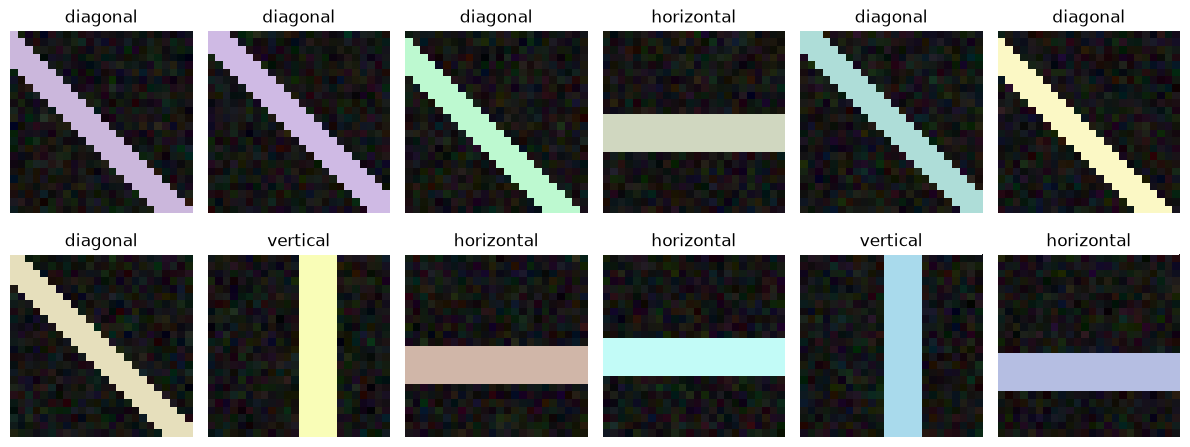

In [2]:
def make_pattern_dataset(number_of_images, seed):
    """Return RGB pattern images (N, 3, 24, 24) and class IDs (N,)."""
    rng = np.random.default_rng(seed)
    labels = rng.integers(0, 3, size=number_of_images)
    images = np.empty((number_of_images, 3, 24, 24), dtype=np.float32)
    rows, columns = np.mgrid[:24, :24]

    for index, label in enumerate(labels):
        image = rng.normal(0.08, 0.035, size=(3, 24, 24))
        foreground_color = rng.uniform(0.65, 1.0, size=(3, 1, 1))
        shift = int(rng.integers(-3, 4))
        if label == 0:
            mask = np.abs(columns - (12 + shift)) <= 2
        elif label == 1:
            mask = np.abs(rows - (12 + shift)) <= 2
        else:
            mask = np.abs((rows - columns) - shift) <= 2
        images[index] = np.clip(
            np.where(mask[None, :, :], foreground_color, image), 0, 1
        )

    return torch.tensor(images), torch.tensor(labels, dtype=torch.long)

train_images, train_labels = make_pattern_dataset(600, seed=4)
validation_images, validation_labels = make_pattern_dataset(150, seed=5)

fig, axes = plt.subplots(2, 6, figsize=(12, 4.8))
for axis, image, label in zip(axes.flatten(), train_images[:12], train_labels[:12]):
    axis.imshow(image.permute(1, 2, 0))
    axis.set_title(CLASS_NAMES[label])
    axis.axis("off")
plt.tight_layout()
plt.show()

## 2. Train a small CNN

The final convolutional tensor has shape $(N,16,12,12)$. Global average pooling reduces it to $(N,16)$, and a linear layer maps those 16 features to three class logits. This particular ending lets us compare CAM and Grad-CAM later.

**CAM** means **Class Activation Mapping** and **Grad-CAM** means **Gradient-weighted Class Activation Mapping**. Both combine deep spatial feature maps into a class-specific heatmap showing where the network found evidence supporting a selected class. CAM weights feature channels using the final linear classifier's learned weights and therefore needs a compatible architecture like this one. Grad-CAM obtains channel importance from gradients of the selected class score, so it works with a broader range of CNNs. Sections 7 and 8 derive both methods step by step.

In [3]:
class PatternCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(16, 3)

    def forward(self, x):
        features = self.features(x)
        pooled = self.pool(features).flatten(1)
        return self.classifier(pooled)

model = PatternCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
batch_size = 64

for epoch in range(6):
    model.train()
    order = torch.randperm(len(train_images))
    for start in range(0, len(train_images), batch_size):
        indexes = order[start:start + batch_size]
        logits = model(train_images[indexes])
        loss = F.cross_entropy(logits, train_labels[indexes])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        predictions = model(validation_images).argmax(dim=1)
        accuracy = (predictions == validation_labels).float().mean().item()
    print(f"epoch {epoch + 1}: validation accuracy={accuracy:.3f}")

assert accuracy > 0.95
example_index = 0
example = validation_images[example_index:example_index + 1]
target_class = int(validation_labels[example_index])
with torch.no_grad():
    predicted_class = int(model(example).argmax(dim=1))
print("target:", CLASS_NAMES[target_class], "prediction:", CLASS_NAMES[predicted_class])

epoch 1: validation accuracy=0.340
epoch 2: validation accuracy=0.727
epoch 3: validation accuracy=1.000
epoch 4: validation accuracy=1.000
epoch 5: validation accuracy=1.000
epoch 6: validation accuracy=1.000
target: diagonal prediction: diagonal


## 3. First-layer filters

The first convolution has weights with shape $(8,3,3,3)$: eight output filters, three RGB input channels, and a $3\times3$ spatial kernel. Each filter can be displayed as a tiny RGB image because its input channels still correspond directly to color.

Weights may be negative and do not naturally lie in the display range $[0,1]$. For visualization only, normalize each filter independently by subtracting its minimum and dividing by its range. Independent normalization reveals structure but hides comparisons of absolute magnitude between filters.

### Exercise 1 — Normalize and display first-layer filters

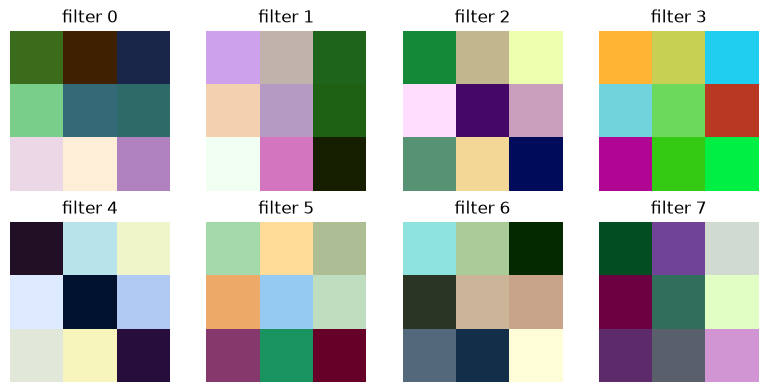

In [4]:
filters = model.features[0].weight.detach().cpu().numpy()
# Find one scalar minimum and maximum for each complete (C, H, W) filter.
# keepdims=True gives shape (8, 1, 1, 1), so each value broadcasts
# across only the corresponding filter.
filter_minimum = filters.min(axis=(1, 2, 3), keepdims=True)
filter_maximum = filters.max(axis=(1, 2, 3), keepdims=True)

# Map each value with (value - minimum) / (maximum - minimum).
# maximum(..., 1e-12) avoids division by zero for a constant filter.
filter_range = np.maximum(filter_maximum - filter_minimum, 1e-12)
normalized_filters = (filters - filter_minimum) / filter_range

assert normalized_filters.shape == (8, 3, 3, 3)
assert normalized_filters.min() >= 0 and normalized_filters.max() <= 1

fig, axes = plt.subplots(2, 4, figsize=(8, 4))
for index, axis in enumerate(axes.flat):
    axis.imshow(np.moveaxis(normalized_filters[index], 0, -1), interpolation="nearest")
    axis.set_title(f"filter {index}")
    axis.axis("off")
plt.tight_layout()
plt.show()

## 4. Intermediate activation maps

A forward hook observes a module's output without changing `forward`. We attach one to the final ReLU. Its output has one $12\times12$ map per channel and per input example. A bright activation means that channel responded strongly at that position; it does not yet prove that the channel caused the final decision.

Hooks remain active until removed, so temporary analysis hooks should always be cleaned up. We pass one example from each of the three pattern classes through the network and compare the same eight channels across them. Each channel uses one shared color scale for all three examples, making response strength within that channel comparable between rows. Scales still differ between channels.

### Exercise 2 — Capture and display deep activations

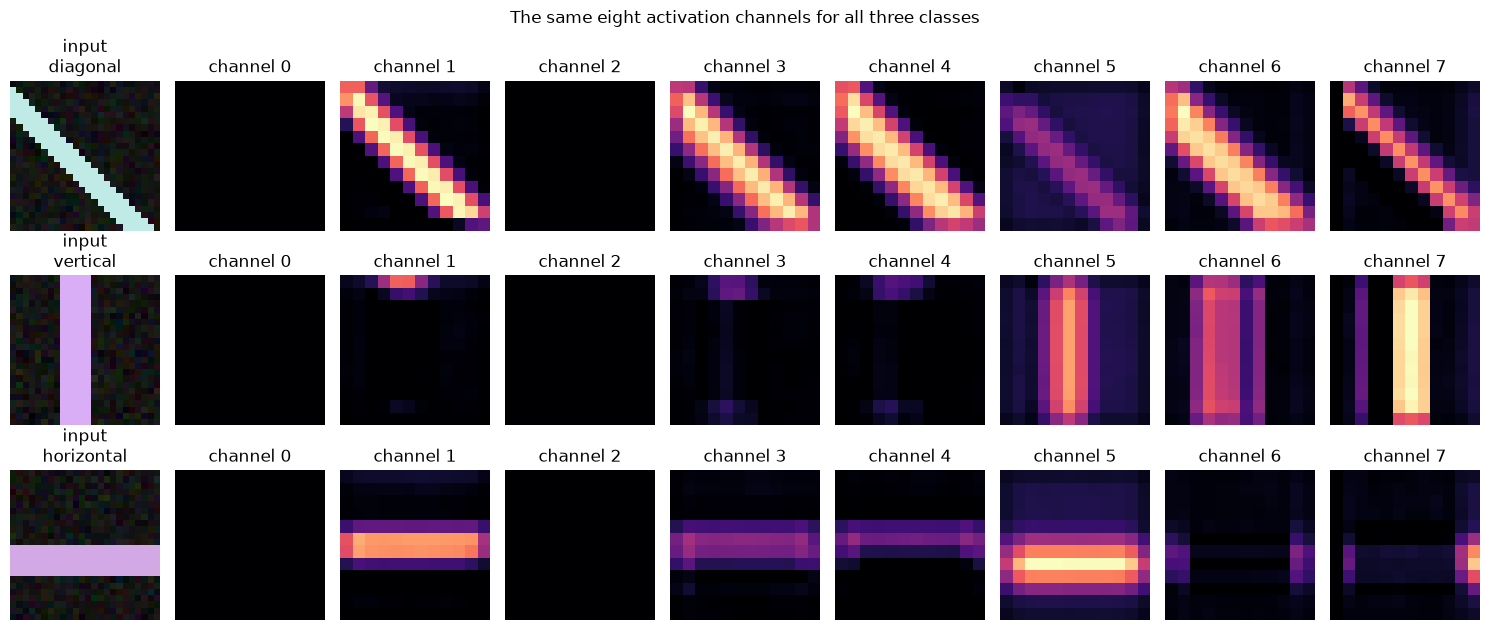

In [5]:
activation_cache = {}

def save_activation(module, inputs, output):
    """Save a snapshot of this module's output during a forward pass."""
    # output is a PyTorch Tensor. detach() disconnects it from autograd,
    # and clone() gives the cache its own tensor storage.
    activation_cache["features"] = output.detach().clone()

activation_indexes = [0, 2, 4]  # diagonal, vertical, horizontal for this seed
activation_examples = validation_images[activation_indexes]
activation_labels = validation_labels[activation_indexes]

hook_handle = model.features[-1].register_forward_hook(save_activation)
try:
    with torch.no_grad():
        _ = model(activation_examples)
finally:
    # Removal also happens if the forward pass raises an exception.
    hook_handle.remove()
deep_activations = activation_cache["features"]

assert deep_activations.shape == (3, 16, 12, 12)
channel_maximum = deep_activations[:, :8].amax(dim=(0, 2, 3))
fig, axes = plt.subplots(3, 9, figsize=(15, 6.5))
for example_index in range(3):
    axes[example_index, 0].imshow(
        activation_examples[example_index].permute(1, 2, 0)
    )
    axes[example_index, 0].set_title(
        f"input\n{CLASS_NAMES[activation_labels[example_index]]}"
    )
    for channel in range(8):
        axes[example_index, channel + 1].imshow(
            deep_activations[example_index, channel],
            cmap="magma", vmin=0, vmax=channel_maximum[channel],
        )
        axes[example_index, channel + 1].set_title(f"channel {channel}")
for axis in axes.flat:
    axis.axis("off")
fig.suptitle("The same eight activation channels for all three classes")
plt.tight_layout()
plt.show()

## 5. Input-gradient saliency

For input image $x$ and class logit $S_c(x)$, saliency starts from

$$
G=\frac{\partial S_c}{\partial x}.
$$

$G$ has the same shape as the input. A large absolute derivative means a small local change to that input value can strongly change the selected class score. Taking the maximum absolute gradient across RGB channels produces one spatial map. We differentiate the raw logit rather than a softmax probability to avoid coupling through the probability normalization.

Saliency is a local sensitivity map, not a guarantee that a pixel is sufficient, causal in every context, or part of the object.

### Exercise 3 — Backpropagate a class score to input pixels

/var/folders/0s/q_d47bvj0hq4rs_6q_06d63m0000gn/T/ipykernel_47148/2532603446.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  assert np.isfinite(normalized_saliency).all()


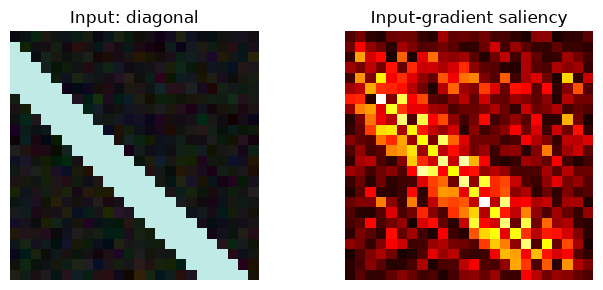

In [6]:
saliency_input = example.detach().clone().requires_grad_(True)
model.zero_grad()
saliency_logits = model(saliency_input)
# Select one scalar: the predicted-class logit for the first example.
selected_score = saliency_logits[0, predicted_class]
selected_score.backward()

# The input gradient has shape (1, 3, 24, 24). Use absolute magnitude
# because either a positive or negative derivative can be important, then
# take the strongest RGB-channel response at every spatial position.
saliency = saliency_input.grad.detach().abs().amax(dim=1)[0]
# Scale the heatmap to [0, 1] for display. clamp_min prevents division by
# zero in the unusual case where every input gradient is exactly zero.
normalized_saliency = saliency / saliency.max().clamp_min(1e-12)

assert normalized_saliency.shape == (24, 24)
assert np.isfinite(normalized_saliency).all()

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(example[0].permute(1, 2, 0))
axes[0].set_title(f"Input: {CLASS_NAMES[predicted_class]}")
axes[1].imshow(normalized_saliency, cmap="hot", vmin=0, vmax=1)
axes[1].set_title("Input-gradient saliency")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

### Reusable input-gradient saliency helper

The exercise above exposes each operation. The helper below packages the same process so we can inspect any single image with shape $(1,C,H,W)$. If `class_id` is omitted, it explains the model's predicted class. Passing a different class ID asks a counterfactual question such as: *which pixels could locally affect the horizontal score for this diagonal image?*

The function temporarily switches the model to evaluation mode and restores its original mode afterward. It returns the heatmap and selected class ID, so the values remain available for later analysis rather than existing only inside the plot.

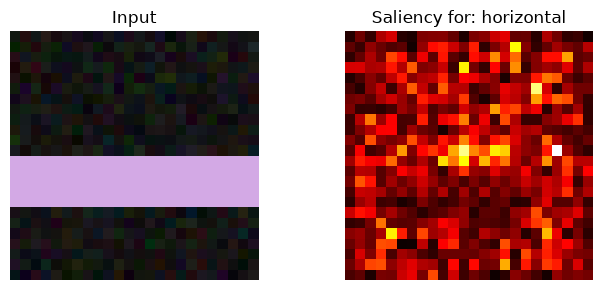

Explained class: horizontal


In [7]:
def visualize_input_gradient_saliency(model, image, class_names, class_id=None):
    """Plot and return saliency for one image and one selected class."""
    if image.ndim != 4 or image.shape[0] != 1:
        raise ValueError("image must have shape (1, C, H, W)")

    was_training = model.training
    model.eval()
    saliency_input = image.detach().clone().requires_grad_(True)
    model.zero_grad(set_to_none=True)

    logits = model(saliency_input)
    if class_id is None:
        class_id = int(logits[0].argmax())
    if class_id < 0 or class_id >= logits.shape[1]:
        raise ValueError("class_id is outside the model's class range")

    logits[0, class_id].backward()
    saliency = saliency_input.grad.detach().abs().amax(dim=1)[0]
    saliency = saliency / saliency.max().clamp_min(1e-12)

    # Move display data to CPU and clear parameter gradients left by backward.
    display_image = image[0].detach().cpu().permute(1, 2, 0)
    display_saliency = saliency.cpu()
    model.zero_grad(set_to_none=True)
    model.train(was_training)

    fig, axes = plt.subplots(1, 2, figsize=(7, 3))
    axes[0].imshow(display_image)
    axes[0].set_title("Input")
    axes[1].imshow(display_saliency, cmap="hot", vmin=0, vmax=1)
    axes[1].set_title(f"Saliency for: {class_names[class_id]}")
    for axis in axes:
        axis.axis("off")
    plt.tight_layout()
    plt.show()
    return display_saliency, class_id

# The helper can now be called with any one-example slice.
horizontal_saliency, explained_class = visualize_input_gradient_saliency(
    model, validation_images[4:5], CLASS_NAMES
)
assert horizontal_saliency.shape == (24, 24)
print("Explained class:", CLASS_NAMES[explained_class])


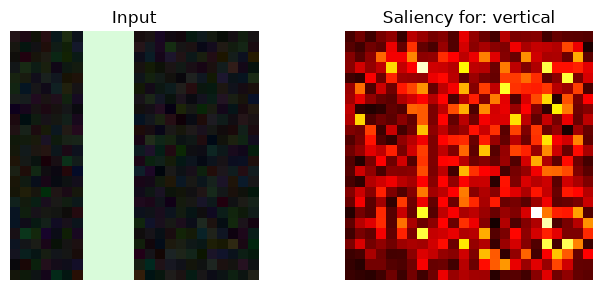

Explained class: vertical


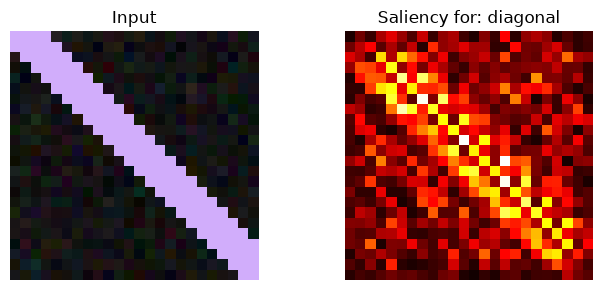

Explained class: diagonal


In [8]:
v_saliency, v_explained_class = visualize_input_gradient_saliency(
    model, validation_images[7:8], CLASS_NAMES
)
assert v_saliency.shape == (24, 24)
print("Explained class:", CLASS_NAMES[v_explained_class])

d_saliency, d_explained_class = visualize_input_gradient_saliency(
    model, validation_images[8:9], CLASS_NAMES
)
assert v_saliency.shape == (24, 24)
print("Explained class:", CLASS_NAMES[d_explained_class])

## 6. Occlusion sensitivity

Occlusion is a perturbation-based alternative to gradients. First record a class score. Then cover one image region, run another forward pass, and measure the score drop:

$$
D_{i,j}=S_c(x)-S_c(x_{\text{occluded at }i,j}).
$$

A positive value means hiding that patch reduced the class score. A negative value means hiding it increased the score. Larger patches give smoother but less precisely localized maps; smaller patches require more forward passes. The result also depends on the replacement value—an artificial black square may itself affect the network.

### Exercise 4 — Scan an occluding patch across the image

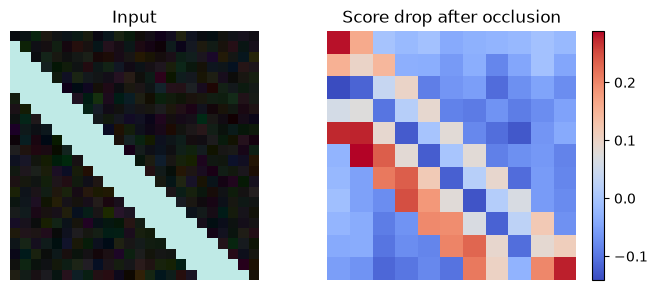

In [13]:
def occlusion_sensitivity(model, image, class_id, patch_size=4, stride=2):
    """Return class-score drops for a sliding mean-valued patch."""
    model.eval()
    with torch.no_grad():
        baseline_score = model(image)[0, class_id].item()
        rows = range(0, image.shape[2] - patch_size + 1, stride)
        columns = range(0, image.shape[3] - patch_size + 1, stride)
        score_drops = np.empty((len(rows), len(columns)))
        replacement = image.mean(dim=(2, 3), keepdim=True)
        for output_row, row in enumerate(rows):
            for output_column, column in enumerate(columns):
                # Clone the complete (N, C, H, W) image. Only this copy is changed.
                occluded = image.detach().clone()
                # Keep every batch item and channel, but replace the spatial patch
                # beginning at pixel coordinates (row, column). The (1, C, 1, 1)
                # replacement value broadcasts across the patch's height and width.
                occluded[:, :, row:row + patch_size, column:column + patch_size] = replacement
                # Measure how much hiding this patch changes the selected class score.
                occluded_score = model(occluded)[0, class_id].item()
                # output_row/output_column locate the result in the smaller map;
                # row/column above locate the corresponding patch in the input image.
                score_drops[output_row, output_column] = baseline_score - occluded_score
    return score_drops

occlusion_map = occlusion_sensitivity(model, example, predicted_class)
assert occlusion_map.shape == (11, 11)
assert np.isfinite(occlusion_map).all()

def plot_occlusion_sensitivity(example, occlusion_map):
    fig, axes = plt.subplots(1, 2, figsize=(7, 3))
    axes[0].imshow(example[0].permute(1, 2, 0))
    axes[0].set_title("Input")
    image_handle = axes[1].imshow(occlusion_map, cmap="coolwarm")
    axes[1].set_title("Score drop after occlusion")
    fig.colorbar(image_handle, ax=axes[1], fraction=0.046)
    for axis in axes:
        axis.axis("off")
    plt.tight_layout()
    plt.show()

plot_occlusion_sensitivity(example, occlusion_map)

Target: vertical; prediction: vertical


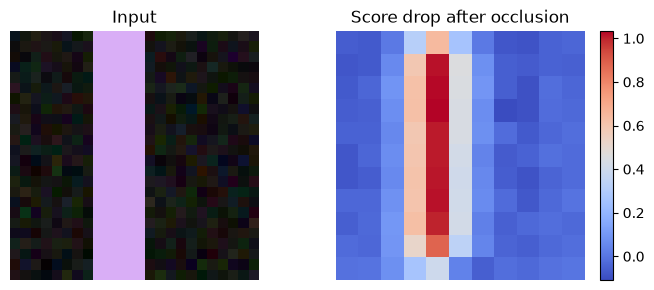

Target: horizontal; prediction: horizontal


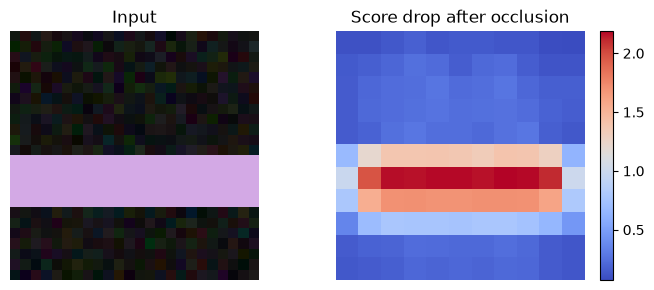

Target: diagonal; prediction: diagonal


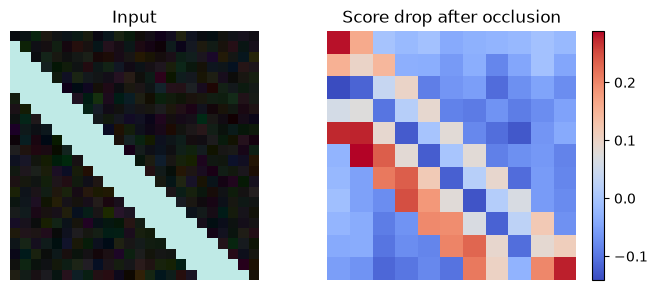

In [14]:
# Visualize one validation example from every class.
for class_id, class_name in enumerate(CLASS_NAMES):
    # Find the first validation image whose ground-truth label is class_id.
    example_index = int(torch.where(validation_labels == class_id)[0][0])
    class_example = validation_images[example_index:example_index + 1]

    with torch.no_grad():
        predicted_id = int(model(class_example).argmax(dim=1)[0])

    # Explain the score of the ground-truth class for this example.
    class_occlusion_map = occlusion_sensitivity(
        model, class_example, class_id, patch_size=4, stride=2
    )
    print(
        f"Target: {class_name}; prediction: {CLASS_NAMES[predicted_id]}"
    )
    plot_occlusion_sensitivity(class_example, class_occlusion_map)

## 7. Class Activation Mapping

CAM applies directly when the last convolutional features $A_{k,h,w}$ are globally averaged and passed to a linear classifier. For class $c$, the classifier weights $W_{c,k}$ say how strongly pooled channel $k$ contributes to that class. Reusing those weights before pooling gives

$$
M^c_{h,w}=\sum_k W_{c,k}A_{k,h,w}.
$$

ReLU keeps positive class-supporting evidence. The $12\times12$ result is then interpolated for display at image resolution. CAM is class-specific and cheap, but this direct derivation requires the global-average-pooling plus linear-classifier architecture.

### Exercise 5 — Weight deep feature maps with class weights

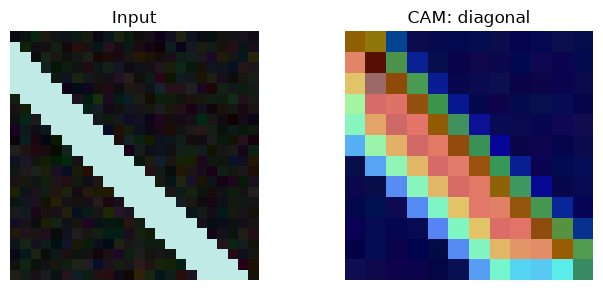

In [21]:
activation = deep_activations[0]  # (K, H, W) = (16, 12, 12)
class_weights = model.classifier.weight.detach()[predicted_class]  # (K,) = (16,)

# Reshape the K class weights to (K, 1, 1), so weight k broadcasts
# across every (h, w) location in activation channel k.
weighted_activations = activation * class_weights[:, None, None]
# Sum only over K. Each spatial location keeps one class-specific value:
# cam[h, w] = sum_k class_weights[k] * activation[k, h, w].
cam = weighted_activations.sum(dim=0)  # (H, W) = (12, 12)

# CAM conventionally displays positive evidence for the selected class.
cam = torch.relu(cam)
# Normalize to [0, 1]; clamp_min protects against an all-zero map.
cam = cam / cam.max().clamp_min(1e-12)

assert cam.shape == (12, 12)
assert torch.isfinite(cam).all()

fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].imshow(example[0].permute(1, 2, 0))
axes[0].set_title("Input")
axes[1].imshow(example[0].permute(1, 2, 0))
axes[1].imshow(cam, cmap="jet", alpha=0.55) # , extent=(0, 24, 24, 0)
axes[1].set_title(f"CAM: {CLASS_NAMES[predicted_class]}")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

### Reusable CAM helper

The helper below performs the complete CAM procedure for any one-example input. By default, it uses this model's final feature layer and linear classifier, but those modules can also be passed explicitly for another CAM-compatible model. The architecture must still end with global average pooling followed by a linear classifier; otherwise the classifier weights do not have the direct CAM interpretation derived above.

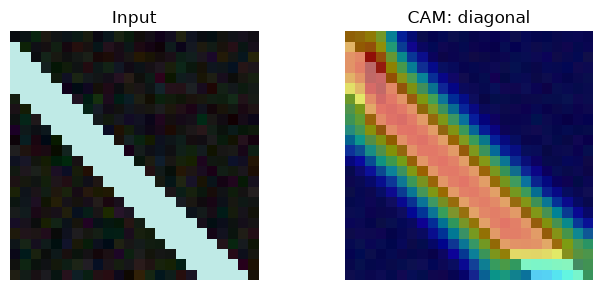

Explained class: diagonal


In [18]:
def visualize_cam(
    model, image, class_names, class_id=None, feature_layer=None, classifier=None
):
    """Calculate, visualize, and return CAM for one image."""
    if image.ndim != 4 or image.shape[0] != 1:
        raise ValueError("image must have shape (1, C, H, W)")

    # These defaults match PatternCNN; explicit modules support similar models.
    feature_layer = model.features[-1] if feature_layer is None else feature_layer
    classifier = model.classifier if classifier is None else classifier
    activation_cache = {}

    def save_cam_activation(module, inputs, output):
        activation_cache["value"] = output.detach()

    was_training = model.training
    model.eval()
    hook_handle = feature_layer.register_forward_hook(save_cam_activation)
    try:
        with torch.no_grad():
            logits = model(image)
    finally:
        hook_handle.remove()
        model.train(was_training)

    if class_id is None:
        class_id = int(logits[0].argmax())
    if class_id < 0 or class_id >= logits.shape[1]:
        raise ValueError("class_id is outside the model's class range")

    # Remove the one-example batch dimension: (1, K, Hf, Wf) -> (K, Hf, Wf).
    activation = activation_cache["value"][0]
    class_weights = classifier.weight.detach()[class_id]
    if activation.shape[0] != class_weights.shape[0]:
        raise ValueError("feature channels must match classifier input features")

    cam = (activation * class_weights[:, None, None]).sum(dim=0)
    cam = torch.relu(cam)
    cam = cam / cam.max().clamp_min(1e-12)

    # Interpolate only for display; return the original feature-resolution CAM.
    display_cam = F.interpolate(
        cam[None, None], size=image.shape[-2:], mode="bilinear", align_corners=False
    )[0, 0].cpu()
    display_image = image[0].detach().cpu().permute(1, 2, 0)

    fig, axes = plt.subplots(1, 2, figsize=(7, 3))
    axes[0].imshow(display_image)
    axes[0].set_title("Input")
    axes[1].imshow(display_image)
    axes[1].imshow(display_cam, cmap="jet", alpha=0.55, vmin=0, vmax=1)
    axes[1].set_title(f"CAM: {class_names[class_id]}")
    for axis in axes:
        axis.axis("off")
    plt.tight_layout()
    plt.show()

    return cam.cpu(), class_id

example_cam, cam_class = visualize_cam(model, example, CLASS_NAMES)
assert example_cam.shape == (12, 12)
assert torch.isfinite(example_cam).all()
print("Explained class:", CLASS_NAMES[cam_class])

## 8. Grad-CAM

Grad-CAM can use a chosen convolutional layer even when direct CAM's architectural assumption does not hold. It differentiates class score $S_c$ with respect to activations and spatially averages those gradients to obtain one importance weight per channel:

$$
\alpha_k^c=\frac{1}{HW}\sum_{h,w}\frac{\partial S_c}{\partial A_{k,h,w}},
$$

$$
M^c=\mathrm{ReLU}\left(\sum_k\alpha_k^c A_k\right).
$$

`retain_grad()` is needed because the activation tensor is not a leaf tensor; PyTorch otherwise retains gradients for parameters and leaf inputs, but not arbitrary intermediate results.

For this particular GAP-plus-linear network, $\alpha_k^c$ is proportional to CAM's classifier weight $W_{c,k}$. Their normalized maps should consequently agree closely. In a more general head, Grad-CAM weights depend on the chosen input and need not equal fixed classifier weights.

### Exercise 6 — Build Grad-CAM from activation gradients

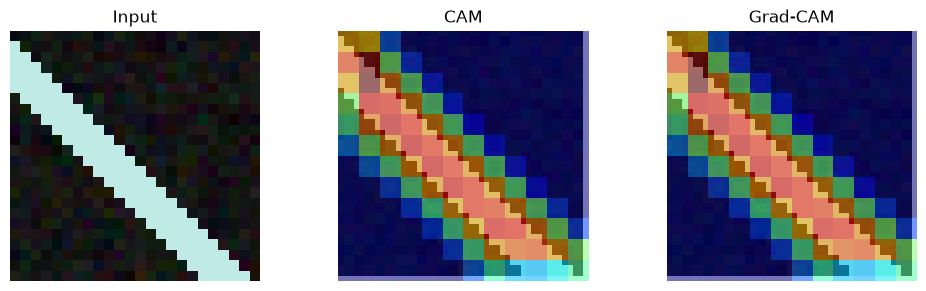

In [22]:
model.zero_grad(set_to_none=True)
gradcam_features = model.features(example)  # (1, 16, 12, 12)
gradcam_features.retain_grad()
gradcam_logits = model.classifier(model.pool(gradcam_features).flatten(1))

# Select one scalar: the predicted-class score for the first example.
gradcam_score = gradcam_logits[0, predicted_class]
# backward() returns None; its result is stored in gradcam_features.grad.
gradcam_score.backward()

# (1, 16, 12, 12) -> (16,): average each channel's gradient over
# the batch and spatial dimensions, leaving one importance weight per channel.
gradient_weights = gradcam_features.grad.mean(dim=(0, 2, 3))

# Weight each feature channel, sum channels, and retain positive evidence.
gradcam = (gradcam_features.detach()[0] * gradient_weights[:, None, None]).sum(dim=0)
gradcam = torch.relu(gradcam)
# Normalize to [0, 1], protecting against an all-zero heatmap.
gradcam = gradcam / gradcam.max().clamp_min(1e-12)

assert gradient_weights.shape == (16,)
assert gradcam.shape == (12, 12)
np.testing.assert_allclose(gradcam.detach(), cam, atol=1e-5)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(example[0].permute(1, 2, 0))
axes[0].set_title("Input")
for axis, heatmap, title in zip(axes[1:], [cam, gradcam], ["CAM", "Grad-CAM"]):
    axis.imshow(example[0].permute(1, 2, 0))
    axis.imshow(heatmap.detach(), cmap="jet", alpha=0.55, extent=(0, 24, 24, 0))
    axis.set_title(title)
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

## 9. What each visualization actually says

| Method | Quantity visualized | Class-specific? | Main limitation |
| --- | --- | --- | --- |
| First-layer filters | Learned RGB kernel weights | No | Only early RGB filters are directly viewable |
| Activation maps | Responses of feature channels | No, unless selected using a class rule | A response is not automatically decision importance |
| Input saliency | Local derivative of a class score with respect to pixels | Yes | Often noisy and only locally valid |
| Occlusion | Score change under a chosen perturbation | Yes | Slow and dependent on patch size/replacement |
| CAM | Class-weighted final feature maps | Yes | Requires a compatible GAP-linear architecture |
| Grad-CAM | Gradient-weighted feature maps | Yes | Coarse and dependent on chosen layer |

A classifier may focus on one discriminative part, use background context, or react to artifacts. A heatmap is therefore evidence for debugging and hypothesis formation—not proof that the model reasons like a human. Compare methods, classes, layers, and perturbed inputs before drawing conclusions.

## Reflection

Answer briefly in your own words.

1. Why can first-layer filters be displayed as RGB images more naturally than deep filters?
2. What is the difference between an activation map and an attribution map?
3. What does a large absolute input gradient mean?
4. Why do we use a raw class logit for saliency?
5. What two choices strongly affect an occlusion map?
6. Why can occlusion score drops be negative?
7. What architectural assumption does direct CAM make?
8. What does a Grad-CAM channel weight $\alpha_k^c$ summarize?
9. Why do CAM and Grad-CAM agree for this particular model?
10. Why should none of these heatmaps be treated as a segmentation mask or complete causal explanation?

### Answers

1. A first-layer filter has three input channels corresponding directly to RGB. Deep filters operate on learned feature channels that do not have a direct color interpretation.
2. An activation map shows where a feature responds, whereas an attribution map estimates which inputs or features influenced a selected output.
3. It means a small local change to that pixel value could strongly change the selected class score. It does not by itself prove causal importance.
4. A raw logit provides a direct class-specific signal without softmax coupling it to every other class probability.
5. The occluding patch size and the value used to replace the covered pixels strongly affect the result.
6. A negative drop means covering that region increased the selected class score, so the original region was suppressing it.
7. Direct CAM assumes global average pooling of the final convolutional features followed by a linear classifier.
8. $\alpha_k^c$ summarizes how sensitive class score $c$ is, on average across spatial positions, to feature channel $k$.
9. With global average pooling and a linear classifier, Grad-CAM's channel weights are proportional to the same classifier weights used by CAM. Normalization removes the shared scale.
10. These maps are coarse or local indicators of model sensitivity and evidence, not pixel-level object labels or complete causal accounts of the decision.